In [1]:
# 09/23
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

cuda
NVIDIA GeForce RTX 5060 Laptop GPU


In [2]:
text = "hello월드😁"

print(len(text))

print(ord('h'))
print(ord('😁'))
print(chr(104))
print(chr(128513))

8
104
128513
h
😁


In [3]:
ids = [ord(char) for char in list(text)]
print(ids)

[104, 101, 108, 108, 111, 50900, 46300, 128513]


In [4]:
class CharTokenizer:
    def encode(self, text):
        return [ord(char) for char in text]
    def decode(self, ids):
        return ''.join([chr(i) for i in ids])

tokenizer = CharTokenizer()
text = 'hello월드😁'

ids = tokenizer.encode(text)
print(ids)

decoded = tokenizer.decode(ids)
print(decoded)

[104, 101, 108, 108, 111, 50900, 46300, 128513]
hello월드😁


In [5]:
encoded = 'A'.encode('utf-8')
print(encoded)
print(list(encoded))

encoded = '가'.encode('utf-8')
print(encoded)
print(list(encoded))

b'A'
[65]
b'\xea\xb0\x80'
[234, 176, 128]


In [6]:
ids = [65]
decoded = bytes(ids).decode('utf-8')
print(decoded)

A


In [7]:
class ByteTokenizer:
    def encode(self, text):
        return list(text.encode('utf-8'))
    def decode(self, ids):
        return bytes(ids).decode('utf-8')

tokenizer = ByteTokenizer()
text = 'hello월드😁'

ids = tokenizer.encode(text)
print(ids)

decoded = tokenizer.decode(ids)
print(decoded)

[104, 101, 108, 108, 111, 236, 155, 148, 235, 147, 156, 240, 159, 152, 129]
hello월드😁


In [8]:
from collections import defaultdict

def count_pairs(ids):
    counts = defaultdict(int)
    for pair in zip(ids, ids[1:]):
        counts[pair] +=1
    return counts

ids = [1, 2, 3, 1, 2]
counts = count_pairs(ids)
print(counts)

defaultdict(<class 'int'>, {(1, 2): 2, (2, 3): 1, (3, 1): 1})


In [9]:
def merge(ids, pair, new_id):
    merge_ids = []
    i=0
    while i < len(ids):
        if i < len(ids) - 1 and (ids[i], ids[i+1]) == pair:
            merge_ids.append(new_id)
            i += 2
        else:
            merge_ids.append(ids[i])
            i += 1
    return merge_ids
ids = [1,2,3,1,2]
merged = merge(ids, (1,2), 4)
print(merged)

[4, 3, 4]


In [10]:
def train_bpe(text, vocab_size):
    ids = list(text.encode('utf-8'))
    num_merges = vocab_size - 256
    merge_rules = {}

    for step in range(num_merges):
        counts = count_pairs(ids)
        if not counts:
            break
        best_pair = max(counts, key=counts.get)
        new_id = 256 + step
        merge_rules[best_pair] = new_id
        ids = merge(ids, best_pair, new_id)
    return merge_rules

text = 'Hello World! This is BPE training'
merge_rules = train_bpe(text, vocab_size=260)
print(merge_rules)

{(105, 115): 256, (256, 32): 257, (105, 110): 258, (72, 101): 259}


In [11]:
class BPETokenizer:
    def __init__(self, merge_rules):
        self.merge_rules = merge_rules
        self.id_to_bytes = {i: bytes([i]) for i in range(256)}
        for (id1, id2), new_id in merge_rules.items():
            self.id_to_bytes[new_id] = self.id_to_bytes[id1] + self.id_to_bytes[id2]
        self.vocab_size = len(self.id_to_bytes)
    def encode(self, text):
        ids = list(text.encode('utf-8'))
        for merge_pair, new_id in self.merge_rules.items():
            ids = merge(ids, merge_pair, new_id)
        return ids
    def decode(self, ids):
        byte_list = [self.id_to_bytes[i] for i in ids]
        combined_bytes = b''.join(byte_list)
        text = combined_bytes.decode('utf-8', errors='replace')
        return text

merge_rules = {(105, 115): 256, (256, 32): 257, (105, 110): 258, (72, 101): 259}

tokenizer = BPETokenizer(merge_rules)

text = 'Hello월드😁'
ids = tokenizer.encode(text)
decoded = tokenizer.decode(ids)

print(ids)
print(decoded)

[259, 108, 108, 111, 236, 155, 148, 235, 147, 156, 240, 159, 152, 129]
Hello월드😁


In [32]:
from collections import defaultdict
import re

def count_pairs(ids, counts = None):
    if counts is None:
        counts = defaultdict(int)

    for pair in zip(ids, ids[1:]):
        counts[pair] += 1
    return counts

def merge(ids, pair, new_id):
    merged_ids = []
    i = 0
    while i < len(ids):
        if i < len(ids) -1 and (ids[i], ids[i+1]) == pair:
            merged_ids.append(new_id)
            i += 2
        else:
            merged_ids.append(ids[i])
            i += 1
    return merged_ids

def train_bpe(input_text, vocab_size, end_token = '<|endoftext|>'):
    texts = input_text.split(end_token)
    ids_list = [list(text.encode('utf-8')) for text in texts]
    num_merges = vocab_size - 256 - 1
    merge_rules = {}

    for step in range(num_merges):
        counts = defaultdict(int)
        for ids in ids_list:
            counts = count_pairs(ids, counts)
        if not counts:
            break
        best_pair = max(counts, key = counts.get)
        new_id = 256 + step
        merge_rules[best_pair] = new_id
        for i in range(len(ids_list)):
            ids_list[i] = merge(ids_list[i], best_pair, new_id)
    return merge_rules

sample_text = 'Hello world!<|endoftext|>This is BPE training.'
merge_rules = train_bpe(sample_text, vocab_size=260)

class BPETokenizer:
    def __init__(self, merge_rules, end_token = '<|endoftext|>'):
        self.merge_rules = merge_rules
        self.end_token = end_token
        self.end_token_id = 256 + len(merge_rules)
        self.id_to_bytes = {i: bytes([i]) for i in range(256)}
        for (id1, id2), new_id in merge_rules.items():
            self.id_to_bytes[new_id] = self.id_to_bytes[id1] + self.id_to_bytes[id2]
        self.id_to_bytes[self.end_token_id] = self.end_token.encode('utf-8')
        self.vocab_size = len(self.id_to_bytes)

    def encode_text(self, text):
        ids = list(text.encode('utf-8'))
        for merge_pair, new_id in self.merge_rules.items():
            ids = merge(ids, merge_pair, new_id)
        return ids

    def encode(self, input_text):
        pattern = '(' + re.escape(self.end_token) + ')'
        texts = re.split(pattern, input_text)
        all_ids = []

        for text in texts:
            if text == self.end_token:
                all_ids.append(self.end_token_id)
            else:
                ids = self.encode_text(text)
                all_ids.extend(ids)
        return all_ids
    
    def decode(self, ids):
        byte_list = [self.id_to_bytes[i] for i in ids]
        text_bytes = b''.join(byte_list)
        text = text_bytes.decode('utf-8', errors='replace')
        return text
    
tokenizer = BPETokenizer(merge_rules)

text = 'Hello world!<|endoftext|>'
ids = tokenizer.encode(text)
decoded = tokenizer.decode(ids)

print(ids)
print(decoded)

[72, 101, 108, 108, 111, 32, 119, 111, 114, 108, 100, 33, 259]
Hello world!<|endoftext|>


In [35]:
from collections import defaultdict
import regex as re
from tqdm import tqdm

def pretokenize(text):
    pattern = r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
    return re.findall(pattern, text)

def count_pairs(ids, counts = None):
    if counts is None:
        counts = defaultdict(int)

    for pair in zip(ids, ids[1:]):
        counts[pair] += 1
    return counts

def merge(ids, pair, new_id):
    merged_ids = []
    i = 0
    while i < len(ids):
        if i < len(ids) -1 and (ids[i], ids[i+1]) == pair:
            merged_ids.append(new_id)
            i += 2
        else:
            merged_ids.append(ids[i])
            i += 1
    return merged_ids

def train_bpe(input_text, vocab_size, end_token='<|endoftext|>'):
    texts = input_text.split(end_token)
    ids_list = [list(text.encode('utf-8')) for text in texts]
    num_merges = vocab_size - 256 - 1
    merge_rules = {}

    for step in range(num_merges):
        texts = input_text.split(end_token)
        ids_list = []
        for text in texts:
            for pretoken in pretokenize(text):
                ids_list.append(list(pretoken.encode('utf-8')))
        num_merges = vocab_size - 256 -1
        merge_rules = {}

        for step in tqdm(range(num_merges), desc='training BPE'):
            counts = defaultdict(int)
            for ids in ids_list:
                counts = count_pairs(ids, counts)
            if not counts:
                break
            best_pair = max(counts, key = counts.get)
            new_id = 256 + step
            merge_rules[best_pair] = new_id
            for i in range(len(ids_list)):
                ids_list[i] = merge(ids_list[i], best_pair, new_id)
    return merge_rules

class BPETokenizer:
    def __init__(self, merge_rules, end_token = '<|endoftext|>'):
        self.merge_rules = merge_rules
        self.end_token = end_token
        self.end_token_id = 256 + len(merge_rules)
        self.id_to_bytes = {i: bytes([i]) for i in range(256)}
        for (id1, id2), new_id in merge_rules.items():
            self.id_to_bytes[new_id] = self.id_to_bytes[id1] + self.id_to_bytes[id2]
        self.id_to_bytes[self.end_token_id] = self.end_token.encode('utf-8')
        self.vocab_size = len(self.id_to_bytes)

    def _encode_text(self, text):
        ids = list(text.encode('utf-8'))
        for merge_pair, new_id in self.merge_rules.items():
            ids = merge(ids, merge_pair, new_id)
        return ids

    def encode(self, input_text, show_progress=False):
        pattern = '(' + re.escape(self.end_token) + ')'
        texts = re.split(pattern, input_text)
        all_ids = []
        texts = tqdm(texts, desc='Encoding') if show_progress else texts
        for text in texts:
            if text == self.end_token:
                all_ids.append(self.end_token_id)
            else:
                for pretoken in pretokenize(text):
                    ids = self._encode_text(pretoken)
                    all_ids.extend(ids)
        return all_ids

    def decode(self, ids):
        byte_list = [self.id_to_bytes[i] for i in ids]
        text_bytes = b''.join(byte_list)
        text = text_bytes.decode('utf-8', errors='replace')
        return text

sample_text = "Say hello! Why hello? Just hell.<|endoftext|>Good morning!"
merge_rules = train_bpe(sample_text, vocab_size=270)
tokenizer = BPETokenizer(merge_rules)

text = 'Say hello!'
ids = tokenizer.encode(text)
decoded = tokenizer.decode(ids)

print(ids)
print(decoded)

for token_id in ids:
    print(f"{token_id} -> '{tokenizer.decode([token_id])}'")

training BPE: 100%|██████████| 13/13 [00:00<?, ?it/s]

[262, 260, 33]
Say hello!
262 -> 'Say'
260 -> ' hello'
33 -> '!'


In [2]:
import sys
import pickle
from codebot.tokenizer import train_bpe

sys.path.append('.')

vocab_size = 1000
text = open('codebot/tiny_codes.txt', encoding='utf-8').read()
merge_rules = train_bpe(text, vocab_size)

with open('codebot/merge_rules.pkl' ,'wb') as f:
    pickle.dump(merge_rules, f)

training BPE: 100%|██████████| 743/743 [12:15<00:00,  1.01it/s]


In [28]:
import sys
from codebot.tokenizer import BPETokenizer

sys.path.append('.')

tokenizer = BPETokenizer.load_from('codebot/merge_rules.pkl')

print('처음 학습된 10')
for token_id in range(256, 266):
    byte_seq = tokenizer.id_to_bytes[token_id]
    text = byte_seq.decode('utf-8', errors='replace')
    print(token_id, text)
print('마지막 학습된 10개')
for token_id in range(990, 1000):
    byte_seq = tokenizer.id_to_bytes[token_id]
    text = byte_seq.decode('utf-8', errors='replace')
    print(token_id, text)

sample_text = open('codebot/tiny_codes.txt', encoding='utf-8').read()[:10000]
byte_count = len(sample_text.encode('utf-8'))
ids = tokenizer.encode(sample_text)
ids_count = len(ids)
compression_ratio = byte_count / ids_count

print('바이트 수:', byte_count)
print('토큰 수:', ids_count)
print('압츅률:', compression_ratio)

처음 학습된 10
256   
257     
258 in
259    
260 re
261 or
262  =
263 st
264 te
265 
   
마지막 학습된 10개
990 Error
991  ''
992 atter
993 St
994 thod
995  on
996 cle
997  R
998 ery
999 <|endoftext|>
바이트 수: 10000
토큰 수: 4709
압츅률: 2.1235931195582927


In [5]:
import sys
import numpy as np
from codebot.tokenizer import BPETokenizer

sys.path.append('.')

tokenizer = BPETokenizer.load_from('codebot/merge_rules.pkl')

text = open('codebot/tiny_codes.txt').read()
ids = tokenizer.encode(text, show_progress=True)

ids_array = np.array(ids, dtype=np.uint16)
ids_array.tofile('codebot/tiny_codes.bin')

print(len(ids_array))
print(ids_array[:20])

Encoding: 100%|██████████| 43671/43671 [03:56<00:00, 185.04it/s]

2677398
[116 528 821 262 544  10 119 717 660  58 265 268 528 107 262 595 338  69
 669 273]


In [29]:
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from itertools import cycle
from tqdm import tqdm

from codebot.model import GPT
from codebot.utils import generate
from codebot.utils import get_device


sys.path.append('.')

device = get_device()
data_path = 'codebot/tiny_codes.bin'
tokenizer_path = 'codebot/merge_rules.pkl'
model_save_path = 'codebot/model_pretrain.pt'

context_len = 256
vocab_size = 1000
batch_size = 32
learning_rate = 3e-4

max_iters = 20000
embed_dim = 384
n_head = 6
n_layers = 6
ff_dim = 4 * embed_dim
dropout_rate = 0.1

In [30]:
class TokenDataset(Dataset):
    def __init__(self, tokens, context_len):
        self.tokens = torch.tensor(tokens, dtype=torch.long)
        self.context_len = context_len

    def __len__(self):
        return len(self.tokens) - self.context_len

    def __getitem__(self, idx):
        x = self.tokens[idx: idx + self.context_len]
        y = self.tokens[idx+1: idx + self.context_len+1]
        return x, y

In [ ]:
import numpy as np

ids = np.fromfile(data_path, dtype=np.uint16)
dataset = TokenDataset(ids, context_len)
dataloader = DataLoader(dataset,
                        batch_size=batch_size,
                        shuffle=True)
model = GPT(vocab_size=vocab_size,
            max_context_len=context_len,
            embed_dim=embed_dim,
            n_head=n_head,
            n_layer=n_layers,
            ff_dim=ff_dim,
            dropout_rate=dropout_rate).to(device)

optimizer = torch.optim.AdamW(model.parameters(),
                              lr = learning_rate)
total_params = sum(p.numel() for p in model.parameters())
print('파라미터수: ', total_params)

losses = []
data_iter = cycle(dataloader)
# for step in pbar:
#     model.train()
#     x, y = next(data)
#     x, y = x.to(device), y.to(device)

#     logits = model(x)
#     loss = F.cross_entropy(logits.view(-1, vocab_size),
#                            y.view(-1))

#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

#     losses.append(loss.item())
#     pbar.set_postfix(loss=f'{loss.item():.4f}')

# model.save(model_save_path)

# plt.plot(losses)
# plt.xlabel('step')
# plt.ylabel('loss')
# plt.show()

파라미터수:  11121640


  0%|          | 0/20000 [00:00<?, ?it/s]

100%|██████████| 20000/20000 [58:09<00:00,  5.73it/s, loss=0.6591]


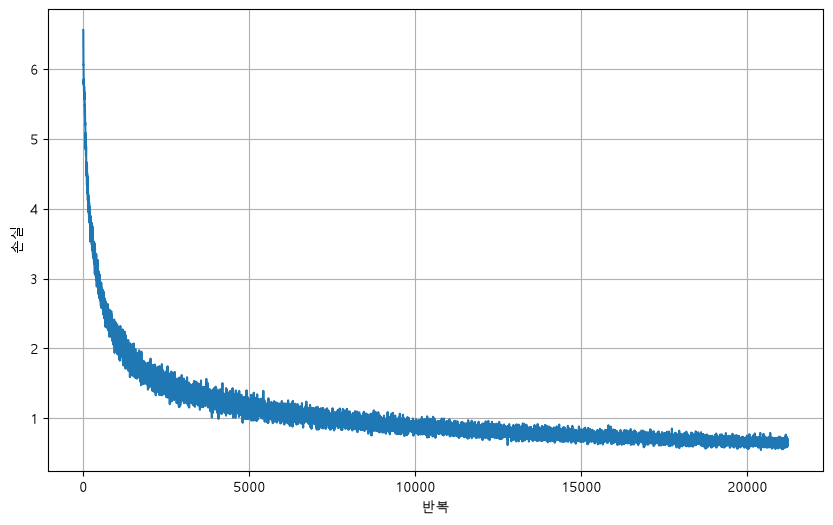

In [35]:
pbar = tqdm(range(max_iters))
for i in pbar:
    batch_x, batch_y = next(data_iter)
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
    logits = model(batch_x)

    loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                           batch_y.view(-1))
    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    losses.append(loss.item())
    pbar.set_postfix({'loss': f'{loss.item():.4f}'})

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10,6))
plt.plot(losses)
plt.xlabel('반복')
plt.ylabel('손실')
plt.grid(True)
plt.savefig('loss.pretrain.png')

model.save(model_save_path)

In [38]:
import sys
sys.path.append('.')

import torch
import torch.nn.functional as F
from codebot.model import GPT
from codebot.tokenizer import BPETokenizer
from codebot.utils import get_device

device = get_device()
print(device)

model_save_path = 'codebot/model_pretrain.pt'
tokenizer_path = 'codebot/merge_rules.pkl'

prompt = 'def'
max_new_tokens = 200
temperature = 1.0

tokenizer = BPETokenizer.load_from(tokenizer_path)
model = GPT.load_from(model_save_path, device=device)

cuda


In [39]:
for i in range(5):
    print(i)
    generated_text = generate(model=model,
                              tokenizer=tokenizer,
                              prompt=prompt,
                              max_new_tokens=max_new_tokens,
                              temperature=temperature)
    print(generated_text)
    print()

0
def join(my_list):
    return [item for item in my_list if item != element]


1
def encrypt(xml_string):
    encrypted_string = ''
    for c in xml_string:
        encrypted_string += chr(encrypted_string)
    return encrypted_string

result = encrypt(encode_string, 3)
print(result)


2
def __init__(self, emp_id):
  self.emp_id = emp_id
  self.emp_id = emp_id
  self.i-1 = emp_id
  self.i-1 = left_node

emp_id = Sort(root)
emp_idx.next = 4
emp_idx.next.next = right_node
emp_idx.next = 2

down = 7

index = Sort(emp_idx.next, emp_idx)
iner_idx.set_idx(emp_idx)

emp_idx = Sort(emp_idx.orlite_node())

emp_node = Sort(emp_idx.data)


3
def swap_array(arr, i, j):
    arr[i], arr[j] = arr[j], arr[i]

    return arr

arr = [3, 5, 2, 7, 9]
selection_sort(arr)
print(arr)


4
def gradient\_interpolation(x, y, h):
 grad = 2 * x
 b = 0
 grad = -3 * x / grad
 cost = 0
 grad = 0
 for i in range(len(x)):
 grad += x.gradient(x[i] - x.shape[i])
 break
 cost = grad * grad
 grad = cost / grad
 cost = cos

In [41]:
import sys

sys.path.append('.')

import json
from codebot.tokenizer import BPETokenizer

tokenizer = BPETokenizer.load_from('codebot/merge_rules.pkl')

with open('codebot/tiny_codes_sft.json') as f:
    data = json.load(f)

item = data[0]
print(item)

# 알파카 포맷
text = f"### Instruction:\n{item['instruction']}\n\n### Response:\n{item['response']}"
print(text)

ids = tokenizer.encode(text)
print(ids)

{'instruction': 'Hello', 'response': 'Hello. What can I help you with?'}
### Instruction:
Hello

### Response:
Hello. What can I help you with?
[35, 35, 35, 962, 519, 117, 389, 58, 10, 846, 10, 10, 35, 35, 35, 752, 568, 58, 10, 846, 46, 840, 104, 277, 280, 356, 473, 708, 108, 112, 930, 657, 63]


In [42]:
import sys
sys.path.append('.')

from itertools import cycle
import json
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from codebot.model import GPT
from codebot.tokenizer import BPETokenizer
from codebot.utils import get_device

In [43]:
device = get_device()
print(device)
data_path = 'codebot/tiny_codes_sft.json'
tokenizer_path = 'codebot/merge_rules.pkl'
pretrain_model_path = 'codebot/model_pretrain.pt'
sft_model_save_path = 'codebot/model_sft.pt'

context_len = 256
batch_size = 32
learning_rate = 3e-4
max_iters = 500

cuda


In [44]:
class SFTDataset(Dataset):
    def __init__(self,
                 data_path,
                 tokenizer,
                 context_len):
        self.tokenizer = tokenizer
        self.context_len = context_len
        self.samples = []

        with open(data_path) as f:
            data = json.load(f)

        for item in data:
            ids, labels = self._create_sample(item['instruction'], item['response'])
            self.samples.append((ids, labels))

    def _create_sample(self, instruction, response):
        prompt = f"### Instruction\n{instruction}\n\n### Response:\n"
        response = f"{response}<|endoftext|>"

        prompt_ids = self.tokenizer.encode(prompt)
        response_ids = self.tokenizer.encode(response)

        ids = prompt_ids + response_ids
        labels = [-100] * len(prompt_ids) + response_ids

        ids = ids[:-1]
        labels = labels[1:]

        pad_len = self.context_len - len(ids)
        if pad_len > 0:
            ids = ids + [0] * pad_len
            labels = labels + [-100] * pad_len
        elif pad_len <0:
            ids = ids[:self.context_len]
            labels = labels[:self.context_len]

        return ids, labels
    
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        ids, labels = self.samples[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

In [46]:
tokenizer = BPETokenizer.load_from(tokenizer_path)
dataset = SFTDataset(data_path, tokenizer, context_len)
dataloader = DataLoader(dataset,
                        batch_size=batch_size,
                        shuffle=True)
model = GPT.load_from(pretrain_model_path, device=device)
optimizer = torch.optim.AdamW(model.parameters(),
                              lr = learning_rate)
losses = []
data_iter = cycle(dataloader)

100%|██████████| 500/500 [01:22<00:00,  6.05it/s, loss=0.1120]


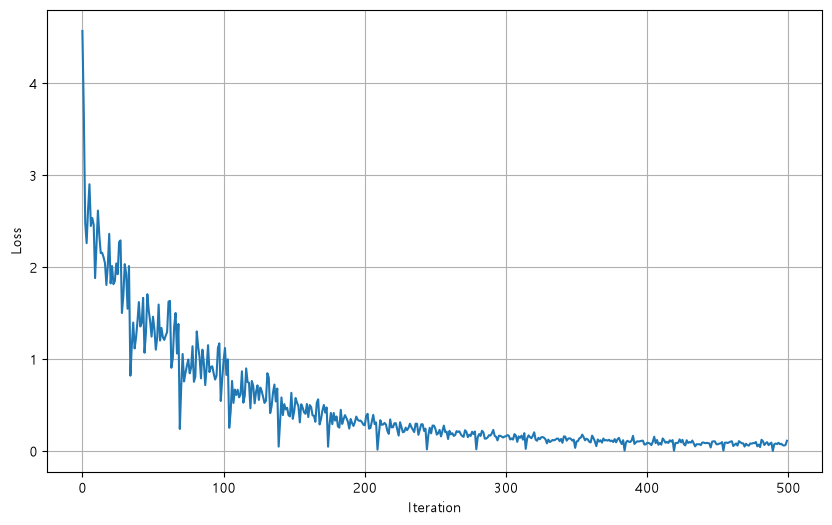

In [47]:
pbar = tqdm(range(max_iters))

for i in pbar:
    batch_x, batch_y = next(data_iter)
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    logits = model(batch_x)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                           batch_y.view(-1),
                           ignore_index=-100)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    pbar.set_postfix({'loss': f'{loss.item():.4f}'})


plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('loss_sft.png')

model.save(sft_model_save_path)

In [49]:
import sys
sys.path.append('.')

from codebot.model import GPT
from codebot.tokenizer import BPETokenizer
from codebot.utils import generate, get_device

device = get_device()
print(device)

model_path = 'codebot/model_sft.pt'
tokenizer_path = 'codebot/merge_rules.pkl'
max_new_tokens = 200
temperature = 1.0

def format_prompt(user_message):
    return f"### Instruction:\n{user_message}\n\n### Response:\n"

tokenizer = BPETokenizer.load_from(tokenizer_path)
model = GPT.load_from(model_path, device=device)

while True:
    user_input = input("\nYou: ").strip()

    if not user_input:
        continue

    prompt = format_prompt(user_input)
    response = generate(model,
                        tokenizer,
                        prompt,
                        max_new_tokens,
                        temperature)
    if "### Response:" in response:
        response = response.split("### Response:")[-1].strip()

    if "\n" in response:
        print(f"Bot:\n{response}")
    else:
        print(f"Bot: {response}")

cuda
Bot: Hello. What can I help you with?
Bot: Hello. What do you need help with?
Bot: quit = 10 // 2


KeyboardInterrupt: Interrupted by user